# COSC 424/525 - Homework 3: BP and NNReview(Part II)(Due Feb. 24)

This homework, again, has ONE problem that revisits the toy example discussed in class. 
You will apply perceptron and multi-layer perceptron (MLP) and gain insights into how 
gradient descent works and how errors are propagated through the network to update weights. 
You must strictly follow the instructions and provide the required outputs at each step. 

**The only file you should submit is this notebook.**
**Both 424/525 students will use both Mary and John’s ratings, hence a 2-dimensional classification problem**

**Problem:** It is Friday night and you’d like to watch a movie. You are considering “Gravity”
and want to choose a movie you are likely to enjoy. You do not want to spend an hour of
your weekend watching a movie only to discover that you dislike it. To help decide, you
called your two friends, Mary and John, and ask for their ratings of “Gravity”, which they
provide. You are also aware of their ratings for 11 other movies that you have already
watched and know whether you “liked” or “disliked”.

**Training Data:**

    •   Movies that Mary rated that I liked, [2.5, 3.5, 3.5, 4.5, 4.5]
    •   Movies that John rated that I liked, in the same order as above, [5, 5, 4, 5, 4]
    •   Movies that Mary rated that I disliked, [1, 1, 1.5, 2.5, 2.5, 2.5]
    •   Movies that John rated that I disliked, in the same order as above, [5, 4, 4, 3, 1.5, 1]

**Testing Data:**

    •   Mary’s rating for “Gravity” is 3
    •   John’s rating for “Gravity” is 3

**Question:**

    •   Should I watch “Gravity”? (or put it another way: will I “like” or “dislike” Gravity?)

You will solve the problem using MLP.

---

## Instructions

1. **Specify your class section below**
2. Complete all parts (a-j) showing detailed work
3. **DON'T DELETE EMPTY TEST CELLS**
4. Run test cells below your answer cells only if they have code in them.
5. Ensure all answer cells are executed, and all outputs are clearly visible

---

## Student Information

**Instructions:** Specify your class section by setting the `CLASS_SECTION` variable to either `"COSC424"` or `"COSC525"`.

In [17]:
# TODO: Set your class section (either "COSC424" or "COSC525")
### BEGIN SOLUTION
CLASS_SECTION = "COSC525"  # INSTRUCTOR SOLUTION - Students should modify this
### END SOLUTION
# CLASS_SECTION = "COSC525 or COSC424"

print(f"Class Section: {CLASS_SECTION}")

Class Section: COSC525


In [18]:
### BEGIN HIDDEN TESTS
# TEST: Verify class section is valid
assert CLASS_SECTION in ["COSC424", "COSC525"], (
    f"Error: CLASS_SECTION must be either 'COSC424' or 'COSC525', but got '{CLASS_SECTION}'"
)
### END HIDDEN TESTS
print(f"✓ Valid class section: {CLASS_SECTION}")
print("=" * 50)

✓ Valid class section: COSC525


---

# Approach 2: Multiple-layer perceptron (MLP)

## a) On activation

If we model the activation function using the sigmoid, that is,

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

and the derivative of sigmoid can be written as $\sigma'(z) = \sigma(z)(1 - \sigma(z))$.

- Write a function "sigmoid(z)" and a function "sigmoid_prime(z)". You can refer to Nielsen's book (ch2).

In [19]:
# Import required library
import numpy as np

# Network architecture: 3-layer MLP (2-3-2)
# - Input layer: 2 nodes (Mary's rating, John's rating)
# - Hidden layer: 3 nodes with sigmoid activation
# - Output layer: 2 nodes (Like, Dislike) with sigmoid activation

In [20]:
# TEST: Verify NumPy is imported
try:
    np.array([1, 2, 3])
    print("✓ NumPy imported successfully")
    print(f"  NumPy version: {np.__version__}")
except NameError:
    print("✗ Error: NumPy not imported")

✓ NumPy imported successfully
  NumPy version: 2.3.5


In [21]:
def sigmoid(z):
    """
    Sigmoid activation function.

    Args:
        z: Input value or array (can be scalar, vector, or matrix)

    Returns:
        Sigmoid activation: σ(z) = 1/(1 + e^(-z))
    """
    ### BEGIN SOLUTION
    return 1.0 / (1.0 + np.exp(-z))
    ### END SOLUTION
    # return ...


def sigmoid_prime(z):
    """
    Derivative of the sigmoid function.

    Args:
        z: Input value or array

    Returns:
        Derivative: σ'(z) = σ(z) * (1 - σ(z))

    Note: This is used during backpropagation to compute gradients.
    """
    ### BEGIN SOLUTION
    return sigmoid(z) * (1 - sigmoid(z))
    ### END SOLUTION
    # return ...


In [22]:
### BEGIN HIDDEN TESTS
# TEST: Verify activation functions work correctly
test_values = np.array([0, 1, -1, 2, -2])
sigmoid_output = sigmoid(test_values)
sigmoid_prime_output = sigmoid_prime(test_values)

print("TEST: Activation Functions")
print("-" * 50)
print(f"Input z:          {test_values}")
print(f"σ(z):             {sigmoid_output}")
print(f"σ'(z):            {sigmoid_prime_output}")
print()

# Verify specific values
assert np.isclose(sigmoid(0), 0.5), "sigmoid(0) should be 0.5"
assert np.isclose(sigmoid_prime(0), 0.25), "sigmoid_prime(0) should be 0.25"
print("✓ Activation function tests passed")
print(f"  - σ(0) = {sigmoid(0):.4f} (expected: 0.5000)")
print(f"  - σ'(0) = {sigmoid_prime(0):.4f} (expected: 0.2500)")
### END HIDDEN TESTS

TEST: Activation Functions
--------------------------------------------------
Input z:          [ 0  1 -1  2 -2]
σ(z):             [0.5        0.73105858 0.26894142 0.88079708 0.11920292]
σ'(z):            [0.25       0.19661193 0.19661193 0.10499359 0.10499359]

✓ Activation function tests passed
  - σ(0) = 0.5000 (expected: 0.5000)
  - σ'(0) = 0.2500 (expected: 0.2500)


---

## b) On initialization

One trick to help with convergence in training is to use symmetric values to initialize the weight.

- Write a function "init_parameters()" that initializes and returns the weights with the following values. (Note 1: in practice, you should use random values. The initial weight is fixed here for grading purpose.) (Note 2: this is the only hardcoded part of this assignment).

$$W^2(0) = \begin{bmatrix} 1 & -1 \\ -1 & 1 \\ 0.5 & -0.5 \end{bmatrix}, \quad W^3(0) = \begin{bmatrix} 0.1 & -0.1 & 0.1 \\ -0.1 & 0.1 & -0.1 \end{bmatrix}$$

$$\mathbf{b}^2(0) = [0 \quad 0 \quad 0]^T, \quad \mathbf{b}^3(0) = [0 \quad 0]^T$$

In [23]:
def init_parameters():
    # # Define network architecture
    # nodes = [X, Y, Z]  # node counts per layer

    # # Initialize weights with specified values
    # W2 = np.array()  # Shape: (3, 2)

    # W3 = np.array()  # Shape: (2, 3)

    # weights = [W2, W3]
    ### BEGIN SOLUTION
    """
    Initialize network parameters with specific values.

    Network architecture: [2, 3, 2]
    - Layer 0 (Input): 2 nodes
    - Layer 1 (Hidden): 3 nodes
    - Layer 2 (Output): 2 nodes

    Returns:
        nodes: List of node counts per layer [2, 3, 2]
        weights: List of weight matrices [W2, W3]
            - W2 (3×2): Connects input layer (2 nodes) to hidden layer (3 nodes)
            - W3 (2×3): Connects hidden layer (3 nodes) to output layer (2 nodes)
        biases: List of bias vectors [b2, b3]
            - b2 (3×1): Bias for hidden layer
            - b3 (2×1): Bias for output layer
    """
    # Define network architecture
    nodes = [2, 3, 2]

    # Initialize weights with specified values
    W2 = np.array([[1.0, -1.0], [-1.0, 1.0], [0.5, -0.5]])  # Shape: (3, 2)

    W3 = np.array([[0.1, -0.1, 0.1], [-0.1, 0.1, -0.1]])  # Shape: (2, 3)

    weights = [W2, W3]

    # Initialize biases to zero
    biases = []
    for i in range(1, len(nodes)):
        b = np.zeros((nodes[i], 1))  # Column vector
        biases.append(b)

    ### END SOLUTION
    return nodes, weights, biases

In [24]:
# TEST: Verify parameter initialization
nodes, weights, biases = init_parameters()

print("TEST: Parameter Initialization")
print("=" * 50)
print(f"Network Architecture: {nodes}")
print()
print(f"W2 (Hidden layer weights) - Shape: {weights[0].shape}")
print(weights[0])
print()
print(f"W3 (Output layer weights) - Shape: {weights[1].shape}")
print(weights[1])
print()
print(f"b2 (Hidden layer bias) - Shape: {biases[0].shape}")
print(biases[0].T)
print()
print(f"b3 (Output layer bias) - Shape: {biases[1].shape}")
print(biases[1].T)
print()

### BEGIN HIDDEN TESTS
# Verify shapes
assert weights[0].shape == (3, 2), f"W2 shape should be (3, 2), got {weights[0].shape}"
assert weights[1].shape == (2, 3), f"W3 shape should be (2, 3), got {weights[1].shape}"
assert biases[0].shape == (3, 1), f"b2 shape should be (3, 1), got {biases[0].shape}"
assert biases[1].shape == (2, 1), f"b3 shape should be (2, 1), got {biases[1].shape}"

print("✓ All parameter shapes are correct")
print("✓ Parameter initialization test passed")
### END HIDDEN TESTS

TEST: Parameter Initialization
Network Architecture: [2, 3, 2]

W2 (Hidden layer weights) - Shape: (3, 2)
[[ 1.  -1. ]
 [-1.   1. ]
 [ 0.5 -0.5]]

W3 (Output layer weights) - Shape: (2, 3)
[[ 0.1 -0.1  0.1]
 [-0.1  0.1 -0.1]]

b2 (Hidden layer bias) - Shape: (3, 1)
[[0. 0. 0.]]

b3 (Output layer bias) - Shape: (2, 1)
[[0. 0.]]

✓ All parameter shapes are correct
✓ Parameter initialization test passed


---

## c) On the feedforward pass

Given a training sample (or in reality, a mini-batch of training samples), x, the forward pass can be carried out using

$$z^2 = W^2 x + b^2, \quad a^2 = \sigma(z^2)$$

$$z^3 = W^3 a^2 + b^3, \quad a^3 = \sigma(z^3)$$

where $x=[x_1, x_2]^T$, $b^2=[b^2_1, b^2_2, b^2_3]^T$, $a^2=[a^2_1, a^2_2, a^2_3]^T$, $z^2=[z^2_1, z^2_2, z^2_3]^T$.

- Write a function "feedforward(weights, biases, x)" where 'weights' and 'biases" are lists of weights and biases in each layer (e.g., weights = [W2, W3], bias = [b2, b3]). Refer to Nielsen's implementation in Network.py. Note that in Nielsen's implementation, these functions are defined within a class. For this homework, however, you should NOT use a class. Instead, implement it as a standard standalone function. The function should return the z's and a's from each layer so that during the backpropagation step, you don't have to recalculate them.

In [25]:
def feedforward(weights, biases, x):
    ### BEGIN SOLUTION
    """
    Perform forward propagation through the network.

    Args:
        weights: List of weight matrices [W2, W3]
        biases: List of bias vectors [b2, b3]
        x: Input vector (2×1 column vector)

    Returns:
        zs: List of pre-activation values [z2, z3]
        activations: List of activations [x, a2, a3]
            - activations[0] = x (input)
            - activations[1] = a2 (hidden layer activation)
            - activations[2] = a3 (output layer activation)

    Forward pass equations:
        z2 = W2 @ x + b2
        a2 = σ(z2)
        z3 = W3 @ a2 + b3
        a3 = σ(z3)
    """
    zs = []
    activations = [x]  # Store input as the first activation (a0 = x)
    a = x

    # Iterate through each layer
    for W, b in zip(weights, biases):
        z = W @ a + b  # Compute weighted sum: z = W·a + b
        a = sigmoid(z)  # Apply activation: a = σ(z)
        zs.append(z)  # Store pre-activation value
        activations.append(a)  # Store activation

    ### END SOLUTION
    return zs, activations

In [26]:
### BEGIN HIDDEN TESTS
### TEST: Verify feedforward function and computation
# Define input vector (Mary's rating, John's rating)
_x = np.array([[5], [3]])  # Shape: (2, 1)
# Perform feedforward pass
_nodes, _weights, _biases = init_parameters()
_zs, _activations = feedforward(_weights, _biases, _x)
assert len(_zs) == 2, f"Expected 2 pre-activation values (z2, z3), got {len(_zs)}"
assert len(_activations) == 3, (
    f"Expected 3 activations (x, a2, a3), got {len(_activations)}"
)

### END HIDDEN TESTS

- Test feedforward() using the first sample, i.e., $x = [2.5 \quad 5]^T$ and output the "zs" and "activations" across layers 2 and 3.

In [27]:
x = np.array([[2.5], [5.0]])
### BEGIN SOLUTION
nodes, weights, biases = init_parameters()
zs, activations = feedforward(weights, biases, x)

print("=" * 60)
print("PART (c): Feedforward Test with x = [2.5, 5]^T")
print("=" * 60)
print(f"\nInput (x):")
print(x.T)
print(f"\n--- Hidden Layer (Layer 2) ---")
print(f"z2 (pre-activation) = W2 @ x + b2:")
print(zs[0].T)
print(f"\na2 (activation) = σ(z2):")
print(activations[1].T)
print(f"\n--- Output Layer (Layer 3) ---")
print(f"z3 (pre-activation) = W3 @ a2 + b3:")
print(zs[1].T)
print(f"\na3 (output) = σ(z3):")
print(activations[2].T)
print(
    f"\nPrediction: {'Like' if activations[2][0, 0] > activations[2][1, 0] else 'Dislike'}"
)
print("=" * 60)
### END SOLUTION
# HINT: zs, activations = feedforward(...
print(f"zs: {zs}")
print(f"activations: {activations}")

PART (c): Feedforward Test with x = [2.5, 5]^T

Input (x):
[[2.5 5. ]]

--- Hidden Layer (Layer 2) ---
z2 (pre-activation) = W2 @ x + b2:
[[-2.5   2.5  -1.25]]

a2 (activation) = σ(z2):
[[0.07585818 0.92414182 0.22270014]]

--- Output Layer (Layer 3) ---
z3 (pre-activation) = W3 @ a2 + b3:
[[-0.06255835  0.06255835]]

a3 (output) = σ(z3):
[[0.48436551 0.51563449]]

Prediction: Dislike
zs: [array([[-2.5 ],
       [ 2.5 ],
       [-1.25]]), array([[-0.06255835],
       [ 0.06255835]])]
activations: [array([[2.5],
       [5. ]]), array([[0.07585818],
       [0.92414182],
       [0.22270014]]), array([[0.48436551],
       [0.51563449]])]


In [28]:
### BEGIN HIDDEN TESTS
# TEST: Verify feedforward output shapes and values
print("\nTEST: Feedforward Verification")
print("-" * 50)

# Test shapes
assert len(zs) == 2, "Should have 2 z vectors (z2 and z3)"
assert len(activations) == 3, "Should have 3 activations (x, a2, a3)"
assert zs[0].shape == (3, 1), f"z2 shape should be (3,1), got {zs[0].shape}"
assert zs[1].shape == (2, 1), f"z3 shape should be (2,1), got {zs[1].shape}"
assert activations[1].shape == (3, 1), (
    f"a2 shape should be (3,1), got {activations[1].shape}"
)
assert activations[2].shape == (2, 1), (
    f"a3 shape should be (2,1), got {activations[2].shape}"
)

# Test that activations are in valid sigmoid range [0, 1]
assert np.all((activations[1] >= 0) & (activations[1] <= 1)), "a2 should be in [0,1]"
assert np.all((activations[2] >= 0) & (activations[2] <= 1)), "a3 should be in [0,1]"

print("✓ All output shapes are correct")
print("✓ All activations in valid range [0, 1]")
print("✓ Feedforward test passed")
### END HIDDEN TESTS


TEST: Feedforward Verification
--------------------------------------------------
✓ All output shapes are correct
✓ All activations in valid range [0, 1]
✓ Feedforward test passed


---

## Training Data Setup

**Data Description:**

**Movies you LIKED** (Output = [1, 0]ᵀ):
- Sample 1: Mary=2.5, John=5
- Sample 2: Mary=3.5, John=5
- Sample 3: Mary=3.5, John=4
- Sample 4: Mary=4.5, John=5
- Sample 5: Mary=4.5, John=4

**Movies you DISLIKED** (Output = [0, 1]ᵀ):
- Sample 6: Mary=1, John=5
- Sample 7: Mary=1, John=4
- Sample 8: Mary=1.5, John=4
- Sample 9: Mary=2.5, John=3
- Sample 10: Mary=2.5, John=1.5
- Sample 11: Mary=2.5, John=1

**Total:** 11 training samples (5 liked + 6 disliked)

In [29]:
# DON'T MODIFY - This code is used to build the training dataset for the MLP
# Movies you liked: (Mary's rating, John's rating)
mary_liked = [2.5, 3.5, 3.5, 4.5, 4.5]
john_liked = [5, 5, 4, 5, 4]

# Movies you disliked: (Mary's rating, John's rating)
mary_disliked = [1, 1, 1.5, 2.5, 2.5, 2.5]
john_disliked = [5, 4, 4, 3, 1.5, 1]

# Build training data: x = [Mary's rating, John's rating]^T
# Label encoding: Like -> y = [1, 0]^T, Dislike -> y = [0, 1]^T
training_data = []

# Add "liked" movies
for m, j in zip(mary_liked, john_liked):
    x = np.array([[m], [j]])  # Input: 2×1 column vector
    y = np.array([[1.0], [0.0]])  # Label: Like
    training_data.append((x, y))

# Add "disliked" movies
for m, j in zip(mary_disliked, john_disliked):
    x = np.array([[m], [j]])  # Input: 2×1 column vector
    y = np.array([[0.0], [1.0]])  # Label: Dislike
    training_data.append((x, y))

print("=" * 60)
print("TRAINING DATA")
print("=" * 60)
print(f"Total training samples: {len(training_data)}")
print(f"  - Liked movies: {len(mary_liked)}")
print(f"  - Disliked movies: {len(mary_disliked)}")
print("\nSample details:")
for i, (x, y) in enumerate(training_data):
    label = "Like" if y[0, 0] == 1 else "Dislike"
    print(
        f"  Sample {i + 1:2d}: x=[{x[0, 0]:.1f}, {x[1, 0]:.1f}] | Label: {label:7s} | y={y.T[0]}"
    )
print("=" * 60)

TRAINING DATA
Total training samples: 11
  - Liked movies: 5
  - Disliked movies: 6

Sample details:
  Sample  1: x=[2.5, 5.0] | Label: Like    | y=[1. 0.]
  Sample  2: x=[3.5, 5.0] | Label: Like    | y=[1. 0.]
  Sample  3: x=[3.5, 4.0] | Label: Like    | y=[1. 0.]
  Sample  4: x=[4.5, 5.0] | Label: Like    | y=[1. 0.]
  Sample  5: x=[4.5, 4.0] | Label: Like    | y=[1. 0.]
  Sample  6: x=[1.0, 5.0] | Label: Dislike | y=[0. 1.]
  Sample  7: x=[1.0, 4.0] | Label: Dislike | y=[0. 1.]
  Sample  8: x=[1.5, 4.0] | Label: Dislike | y=[0. 1.]
  Sample  9: x=[2.5, 3.0] | Label: Dislike | y=[0. 1.]
  Sample 10: x=[2.5, 1.5] | Label: Dislike | y=[0. 1.]
  Sample 11: x=[2.5, 1.0] | Label: Dislike | y=[0. 1.]


In [30]:
### BEGIN HIDDEN TESTS
# TEST: Verify training data
print("\nTEST: Training Data Verification")
print("-" * 50)

assert len(training_data) == 11, f"Should have 11 samples, got {len(training_data)}"
assert len([y for x, y in training_data if y[0, 0] == 1]) == 5, (
    "Should have 5 'like' samples"
)
assert len([y for x, y in training_data if y[1, 0] == 1]) == 6, (
    "Should have 6 'dislike' samples"
)

# Verify data format
for i, (x, y) in enumerate(training_data):
    assert x.shape == (2, 1), f"Sample {i + 1}: x shape should be (2,1)"
    assert y.shape == (2, 1), f"Sample {i + 1}: y shape should be (2,1)"
    assert np.sum(y) == 1, f"Sample {i + 1}: y should have exactly one '1'"

print("✓ Training data has correct structure")
print("✓ All samples have correct shape")
print("✓ Training data verification passed")
### END HIDDEN TESTS


TEST: Training Data Verification
--------------------------------------------------
✓ Training data has correct structure
✓ All samples have correct shape
✓ Training data verification passed


---

## d) On backpropagation and Gradient Calculation

Calculate the error in the output and propagate this error backward through the network to update the weights.

- **525 students only:** Derive $\frac{\partial C}{\partial w_i^3(k)}$ and $\frac{\partial C}{\partial w^2(k)}$ in detail following the chain rule.

**Derivation (using the forward/backward propagation diagram):**

Let the cost for one sample be
$$C=\frac{1}{2}\sum_{j=1}^{2}(a_j^3-y_j)^2,$$
with
$$z^2 = W^2 x + b^2,\quad a^2 = \sigma(z^2),\quad z^3 = W^3 a^2 + b^3,\quad a^3 = \sigma(z^3).$$

**Output layer ($W^3$):**
For weight from hidden unit $i$ to output unit $j$ ($w^3_{ji}$):
$$\frac{\partial C}{\partial w^3_{ji}}
=\frac{\partial C}{\partial a^3_j}\frac{\partial a^3_j}{\partial z^3_j}\frac{\partial z^3_j}{\partial w^3_{ji}}
=(a^3_j-y_j)\,\sigma'(z^3_j)\,a^2_i.$$
Define
$$\delta^3_j=(a^3_j-y_j)\,\sigma'(z^3_j),$$
then
$$\nabla W^3 = \delta^3 (a^2)^T,\quad \nabla b^3=\delta^3.$$

**Hidden layer ($W^2$):**
For weight from input $\ell$ to hidden unit $i$ ($w^2_{i\ell}$):
$$\frac{\partial C}{\partial w^2_{i\ell}}
=\sum_{j=1}^{2}\frac{\partial C}{\partial a^3_j}\frac{\partial a^3_j}{\partial z^3_j}\frac{\partial z^3_j}{\partial a^2_i}\frac{\partial a^2_i}{\partial z^2_i}\frac{\partial z^2_i}{\partial w^2_{i\ell}}$$
$$=\sum_{j=1}^{2}(a^3_j-y_j)\,\sigma'(z^3_j)\,w^3_{ji}\,\sigma'(z^2_i)\,x_{\ell}.$$
Define
$$\delta^2_i=\left(\sum_{j=1}^{2} w^3_{ji}\,\delta^3_j\right)\sigma'(z^2_i),$$
then
$$\nabla W^2 = \delta^2 x^T,\quad \nabla b^2=\delta^2.$$

- Write a function "backprop(activations, zs, weights, biases, y)" and return the updated weights. There need to be five arguments of this function, where "activations" and "zs" are returned by feedforward() in c) that store the activation values and sum-of-product values of every layer (i.e., layers 2 and 3) calculated from the forward pass; "weights" and "biases" provide the current weights and biases to be updated, and "y" is the ground truth for the input "x". This function should return the changes to weights (i.e., $\frac{\partial C}{\partial w_i^3(k)}$ and $\frac{\partial C}{\partial w^2(k)}$) and changes to biases.

In [31]:
def backprop(activations, zs, weights, biases, y):
    ### BEGIN SOLUTION
    """
    Backpropagation algorithm to compute gradients of cost w.r.t. weights and biases.

    Uses Mean Squared Error (MSE) cost: C = (1/2)||a³ - y||²

    Args:
        activations: List of activations from feedforward [x, a2, a3]
            - activations[0] = x (input, 2×1)
            - activations[1] = a2 (hidden layer, 3×1)
            - activations[2] = a3 (output layer, 2×1)
        zs: List of pre-activation values [z2, z3]
        weights: List of weight matrices [W2, W3]
        biases: List of bias vectors [b2, b3]
        y: Ground truth label (2×1 column vector)

    Returns:
        nabla_ws: List of gradients for weights [∇W2, ∇W3]
            - ∇W2: Gradient of cost with respect to W2 (shape: 3×2)
            - ∇W3: Gradient of cost with respect to W3 (shape: 2×3)
        nabla_bs: List of gradients for biases [∇b2, ∇b3]
            - ∇b2: Gradient of cost with respect to b2 (shape: 3×1)
            - ∇b3: Gradient of cost with respect to b3 (shape: 2×1)

    Backpropagation equations:
        Output layer (L=3):
            δ³ = (a³ - y) ⊙ σ'(z³)  [Element-wise product]
            ∇W³ = δ³ @ (a²)ᵀ  [Outer product: (2×1) @ (1×3) = (2×3)]
            ∇b³ = δ³

        Hidden layer (L=2):
            δ² = ((W³)ᵀ @ δ³) ⊙ σ'(z²)  [Backpropagation of error]
            ∇W² = δ² @ xᵀ  [Outer product: (3×1) @ (1×2) = (3×2)]
            ∇b² = δ²
    """
    # Initialize gradient storage
    nabla_ws = [np.zeros(W.shape) for W in weights]
    nabla_bs = [np.zeros(b.shape) for b in biases]

    # STEP 1: Compute output layer error (L=3)
    # δ³ = (a³ - y) ⊙ σ'(z³)
    delta = (activations[-1] - y) * sigmoid_prime(zs[-1])

    # STEP 2: Compute output layer gradients (L=3)
    # ∇W³ = δ³ @ (a²)ᵀ
    # ∇b³ = δ³
    nabla_bs[-1] = delta
    nabla_ws[-1] = delta @ activations[-2].T

    # STEP 3 & 4: Backpropagate error to hidden layer (L=2)
    # δ² = ((W³)ᵀ @ δ³) ⊙ σ'(z²)
    # ∇W² = δ² @ (a¹)ᵀ = δ² @ xᵀ
    # ∇b² = δ²
    for l in range(2, len(weights) + 1):
        # Backpropagate delta from layer l+1 to layer l
        z = zs[-l]  # Pre-activation of current layer
        sp = sigmoid_prime(z)  # σ'(z^l)

        # δ^l = ((W^(l+1))ᵀ @ δ^(l+1)) ⊙ σ'(z^l)
        delta = (weights[-l + 1].T @ delta) * sp

        # Compute gradients for weights and biases of layer l
        nabla_bs[-l] = delta
        nabla_ws[-l] = delta @ activations[-l - 1].T

    ### END SOLUTION
    return nabla_ws, nabla_bs

In [32]:
### BEGIN HIDDEN TESTS
# TEST: Verify backpropagation gradient computation
print("\nTEST: Backpropagation Function Verification")
print("-" * 50)

# Use test data to verify backpropagation
_x = np.array([[5], [3]])  # Shape: (2, 1)
_y = np.array([[1], [0]])  # Shape: (2, 1) - "Like" label

# Initialize fresh parameters
_nodes, _weights, _biases = init_parameters()

# Perform feedforward pass
_zs, _activations = feedforward(_weights, _biases, _x)

# Perform backpropagation
_nabla_ws, _nabla_bs = backprop(_activations, _zs, _weights, _biases, _y)

# Verify shapes match weights/biases
assert len(_nabla_ws) == 2, "Should return 2 weight gradient matrices"
assert len(_nabla_bs) == 2, "Should return 2 bias gradient vectors"

assert _nabla_ws[0].shape == _weights[0].shape, (
    f"∇W2 shape {_nabla_ws[0].shape} should match W2 shape {_weights[0].shape}"
)
assert _nabla_ws[1].shape == _weights[1].shape, (
    f"∇W3 shape {_nabla_ws[1].shape} should match W3 shape {_weights[1].shape}"
)
assert _nabla_bs[0].shape == _biases[0].shape, (
    f"∇b2 shape {_nabla_bs[0].shape} should match b2 shape {_biases[0].shape}"
)
assert _nabla_bs[1].shape == _biases[1].shape, (
    f"∇b3 shape {_nabla_bs[1].shape} should match b3 shape {_biases[1].shape}"
)

# Verify that gradients are computed (should not be all zeros)
assert np.any(_nabla_ws[0] != 0), "∇W2 should contain non-zero values"
assert np.any(_nabla_ws[1] != 0), "∇W3 should contain non-zero values"
assert np.any(_nabla_bs[0] != 0), "∇b2 should contain non-zero values"
assert np.any(_nabla_bs[1] != 0), "∇b3 should contain non-zero values"

print("✓ Returned 2 gradient matrices and 2 gradient vectors")
print(f"✓ ∇W2 shape: {_nabla_ws[0].shape} (matches W2)")
print(f"✓ ∇W3 shape: {_nabla_ws[1].shape} (matches W3)")
print(f"✓ ∇b2 shape: {_nabla_bs[0].shape} (matches b2)")
print(f"✓ ∇b3 shape: {_nabla_bs[1].shape} (matches b3)")
print("✓ All gradients contain non-zero values")
print("✓ Backpropagation function test passed")
### END HIDDEN TESTS


TEST: Backpropagation Function Verification
--------------------------------------------------
✓ Returned 2 gradient matrices and 2 gradient vectors
✓ ∇W2 shape: (3, 2) (matches W2)
✓ ∇W3 shape: (2, 3) (matches W3)
✓ ∇b2 shape: (3, 1) (matches b2)
✓ ∇b3 shape: (2, 1) (matches b3)
✓ All gradients contain non-zero values
✓ Backpropagation function test passed


- Again, test backprop() using the first sample, i.e., $x = [2.5 \quad 5]^T$ and output "nabla_bs" and "nabla_ws" across layers 2 and 3.

In [33]:
### BEGIN SOLUTION
x = np.array([[2.5], [5.0]])
y = np.array([[1.0], [0.0]])  # Like

nodes, weights, biases = init_parameters()
zs, activations = feedforward(weights, biases, x)
nabla_ws, nabla_bs = backprop(activations, zs, weights, biases, y)

print("=" * 60)
print("PART (d): Backpropagation Test")
print("=" * 60)
print(f"Input: x = {x.T[0]}")
print(f"Label: y = {y.T[0]} (Like)")
print(f"Network output: a³ = {activations[-1].T[0]}")
print(f"Error: (a³ - y) = {(activations[-1] - y).T[0]}")
print(f"\n--- Computed Gradients ---")
print(f"\n∇W2 (dC/dW2) - Shape: {nabla_ws[0].shape}")
print(nabla_ws[0])
print(f"\n∇b2 (dC/db2) - Shape: {nabla_bs[0].shape}")
print(nabla_bs[0].T)
print(f"\n∇W3 (dC/dW3) - Shape: {nabla_ws[1].shape}")
print(nabla_ws[1])
print(f"\n∇b3 (dC/db3) - Shape: {nabla_bs[1].shape}")
print(nabla_bs[1].T)
print("=" * 60)
### END SOLUTION
# HINT:
#  Get the activations and zs from the feedforward pass to compute gradients, then
#  nabla_ws, nabla_bs = backprop(...
print(f"nabla_ws: {nabla_ws}")
print(f"nabla_bs: {nabla_bs}")

PART (d): Backpropagation Test
Input: x = [2.5 5. ]
Label: y = [1. 0.] (Like)
Network output: a³ = [0.48436551 0.51563449]
Error: (a³ - y) = [-0.51563449  0.51563449]

--- Computed Gradients ---

∇W2 (dC/dW2) - Shape: (3, 2)
[[-0.00451407 -0.00902814]
 [ 0.00451407  0.00902814]
 [-0.01114644 -0.02229288]]

∇b2 (dC/db2) - Shape: (3, 1)
[[-0.00180563  0.00180563 -0.00445858]]

∇W3 (dC/dW3) - Shape: (2, 3)
[[-0.00976921 -0.11901337 -0.0286799 ]
 [ 0.00976921  0.11901337  0.0286799 ]]

∇b3 (dC/db3) - Shape: (2, 1)
[[-0.12878258  0.12878258]]
nabla_ws: [array([[-0.00451407, -0.00902814],
       [ 0.00451407,  0.00902814],
       [-0.01114644, -0.02229288]]), array([[-0.00976921, -0.11901337, -0.0286799 ],
       [ 0.00976921,  0.11901337,  0.0286799 ]])]
nabla_bs: [array([[-0.00180563],
       [ 0.00180563],
       [-0.00445858]]), array([[-0.12878258],
       [ 0.12878258]])]


In [34]:
### BEGIN HIDDEN TESTS
# TEST: Verify backpropagation gradients from part (d)
print("\nTEST: Backpropagation Output Verification")
print("-" * 50)

# Verify gradient shapes match weight/bias shapes
assert nabla_ws[0].shape == weights[0].shape, (
    f"∇W2 shape {nabla_ws[0].shape} should match W2 shape {weights[0].shape}"
)
assert nabla_ws[1].shape == weights[1].shape, (
    f"∇W3 shape {nabla_ws[1].shape} should match W3 shape {weights[1].shape}"
)
assert nabla_bs[0].shape == biases[0].shape, (
    f"∇b2 shape {nabla_bs[0].shape} should match b2 shape {biases[0].shape}"
)
assert nabla_bs[1].shape == biases[1].shape, (
    f"∇b3 shape {nabla_bs[1].shape} should match b3 shape {biases[1].shape}"
)

# Gradients should be non-zero (learning signal exists)
assert np.any(nabla_ws[0] != 0), "∇W2 should have non-zero values"
assert np.any(nabla_ws[1] != 0), "∇W3 should have non-zero values"
assert np.any(nabla_bs[0] != 0), "∇b2 should have non-zero values"
assert np.any(nabla_bs[1] != 0), "∇b3 should have non-zero values"

# Verify gradients are finite
assert np.all(np.isfinite(nabla_ws[0])), "∇W2 should contain finite values"
assert np.all(np.isfinite(nabla_ws[1])), "∇W3 should contain finite values"
assert np.all(np.isfinite(nabla_bs[0])), "∇b2 should contain finite values"
assert np.all(np.isfinite(nabla_bs[1])), "∇b3 should contain finite values"

print("✓ All gradient shapes match weight/bias shapes")
print("✓ Gradients contain non-zero values")
print("✓ All gradients are finite")
print("✓ Backpropagation test passed")
### END HIDDEN TESTS


TEST: Backpropagation Output Verification
--------------------------------------------------
✓ All gradient shapes match weight/bias shapes
✓ Gradients contain non-zero values
✓ All gradients are finite
✓ Backpropagation test passed


---

## e) On weight update

Based on the returned gradient from d), update all the weights using gradient descent. That is,

$$W(k+1) = W(k) - \eta \frac{\partial C}{\partial W(k)}$$

- Write a function "update(weights, biases, nabla_ws, nabla_bs)" to carry out the updates

In [35]:
def update(weights, biases, nabla_ws, nabla_bs, eta=0.5):
    ### BEGIN SOLUTION
    """
    Update weights and biases using gradient descent.

    Args:
        weights: Current weight matrices [W2, W3]
        biases: Current bias vectors [b2, b3]
        nabla_ws: Gradients for weights [∇W2, ∇W3]
        nabla_bs: Gradients for biases [∇b2, ∇b3]
        eta: Learning rate (default: 0.5)

    Returns:
        weights: Updated weight matrices
        biases: Updated bias vectors

    Update equations:
        W_new = W_old - η * ∇W
        b_new = b_old - η * ∇b
    """
    weights = [W - eta * nw for W, nw in zip(weights, nabla_ws)]
    biases = [b - eta * nb for b, nb in zip(biases, nabla_bs)]
    ### END SOLUTION
    return weights, biases

In [36]:
### BEGIN HIDDEN TESTS
# TEST: Verify update function
print("\nTEST: Update Function Verification")
print("-" * 50)
# Use the same gradients from the backpropagation test
_learning_rate = 0.01
_updated_weights, _updated_biases = update(
    _weights, _biases, _nabla_ws, _nabla_bs, eta=_learning_rate
)
assert len(_updated_weights) == len(_weights), (
    "Number of weight matrices should not change"
)
assert len(_updated_biases) == len(_biases), "Number of bias vectors should not change"
assert _updated_weights[0].shape == _weights[0].shape, (
    "Updated W2 shape should match original W2 shape"
)
assert _updated_weights[1].shape == _weights[1].shape, (
    "Updated W3 shape should match original W3 shape"
)
assert _updated_biases[0].shape == _biases[0].shape, (
    "Updated b2 shape should match original b2 shape"
)
assert _updated_biases[1].shape == _biases[1].shape, (
    "Updated b3 shape should match original b3 shape"
)
print("✓ Updated weights and biases have correct shapes")
print("✓ Update function test passed")
### END HIDDEN TESTS


TEST: Update Function Verification
--------------------------------------------------
✓ Updated weights and biases have correct shapes
✓ Update function test passed


- Use $x = [2.5 \quad 5]^T$ as the input to test "update()" and output the weights and biases in the same format as that of the initial value

$$W^2(0) = \begin{bmatrix} 1 & -1 \\ -1 & 1 \\ 0.5 & -0.5 \end{bmatrix}, \quad W^3(0) = \begin{bmatrix} 0.1 & -0.1 & 0.1 \\ -0.1 & 0.1 & -0.1 \end{bmatrix}$$

$$\mathbf{b}^2(0) = [0 \quad 0 \quad 0]^T, \quad \mathbf{b}^3(0) = [0 \quad 0]^T$$

In [37]:
### BEGIN SOLUTION
x = np.array([[2.5], [5.0]])
y = np.array([[1.0], [0.0]])  # Like
eta = 0.5

# Initialize parameters
nodes, weights, biases = init_parameters()

# Store original parameters for comparison
W2_old = weights[0].copy()
W3_old = weights[1].copy()

# Forward pass
zs, activations = feedforward(weights, biases, x)

# Backward pass
nabla_ws, nabla_bs = backprop(activations, zs, weights, biases, y)

# Update parameters
weights, biases = update(weights, biases, nabla_ws, nabla_bs, eta)

print("=" * 60)
print(f"PART (e): Parameter Update (η={eta})")
print("=" * 60)
print(f"\nInput: x = {x.T[0]}, Label: y = {y.T[0]} (Like)")
print(f"\n--- Updated Weights & Biases ---")
print(f"\nW2(1) - Shape: {weights[0].shape}")
print(weights[0])
print(f"\nW3(1) - Shape: {weights[1].shape}")
print(weights[1])
print(f"\nb2(1) - Shape: {biases[0].shape}")
print(biases[0].T)
print(f"\nb3(1) - Shape: {biases[1].shape}")
print(biases[1].T)
print("=" * 60)
### END SOLUTION
# HINT:
# Get the gradients from backpropagation, then update the parameters using the update function, e.g.
# weights, biases = update(...
print(f"Updated weights: {weights}")
print(f"Updated biases: {biases}")

PART (e): Parameter Update (η=0.5)

Input: x = [2.5 5. ], Label: y = [1. 0.] (Like)

--- Updated Weights & Biases ---

W2(1) - Shape: (3, 2)
[[ 1.00225703 -0.99548593]
 [-1.00225703  0.99548593]
 [ 0.50557322 -0.48885356]]

W3(1) - Shape: (2, 3)
[[ 0.10488461 -0.04049332  0.11433995]
 [-0.10488461  0.04049332 -0.11433995]]

b2(1) - Shape: (3, 1)
[[ 0.00090281 -0.00090281  0.00222929]]

b3(1) - Shape: (2, 1)
[[ 0.06439129 -0.06439129]]
Updated weights: [array([[ 1.00225703, -0.99548593],
       [-1.00225703,  0.99548593],
       [ 0.50557322, -0.48885356]]), array([[ 0.10488461, -0.04049332,  0.11433995],
       [-0.10488461,  0.04049332, -0.11433995]])]
Updated biases: [array([[ 0.00090281],
       [-0.00090281],
       [ 0.00222929]]), array([[ 0.06439129],
       [-0.06439129]])]


In [38]:
### BEGIN HIDDEN TESTS
# TEST: Verify parameters were updated
print("\nTEST: Parameter Update Verification")
print("-" * 50)

# Verify parameters changed
W2_changed = not np.allclose(weights[0], W2_old)
W3_changed = not np.allclose(weights[1], W3_old)

assert W2_changed, "W2 should have changed after update"
assert W3_changed, "W3 should have changed after update"

# Verify shapes remain the same
assert weights[0].shape == (3, 2), "W2 shape should remain (3, 2)"
assert weights[1].shape == (2, 3), "W3 shape should remain (2, 3)"

print("✓ Parameters successfully updated")
print("✓ All shapes preserved after update")
print("✓ Parameter update test passed")
### END HIDDEN TESTS


TEST: Parameter Update Verification
--------------------------------------------------
✓ Parameters successfully updated
✓ All shapes preserved after update
✓ Parameter update test passed


---

## f) Repeat c)-e) for all the rest 10 training samples

Congratulations! You have finished one epoch of the MLP training!

In [39]:
eta = 0.5  # Learning rate for training # DON`T MODIFY
### BEGIN SOLUTION
nodes, weights, biases = init_parameters()

print("=" * 60)
print("PART (f): Training for One Epoch")
print("=" * 60)
print(f"Learning rate (η): {eta}")
print(f"Total samples: {len(training_data)}")
print("\n--- Training Progress ---\n")

for i, (x, y) in enumerate(training_data):
    # Forward pass
    zs, activations = feedforward(weights, biases, x)

    # Backward pass
    nabla_ws, nabla_bs = backprop(activations, zs, weights, biases, y)

    # Update weights and biases
    weights, biases = update(weights, biases, nabla_ws, nabla_bs, eta)

    # Display progress
    label = "Like" if y[0, 0] == 1 else "Dislike"
    output = activations[-1]
    print(
        f"Sample {i + 1:2d}: x=[{x[0, 0]:.1f}, {x[1, 0]:.1f}] ({label:7s}) "
        f"→ output=[{output[0, 0]:.4f}, {output[1, 0]:.4f}]"
    )

### END SOLUTION
# HINT: Loop through the training data, perform feedforward, backpropagation, and update for each sample
print("\n" + "=" * 60)
print("Final Weights & Biases After 1 Epoch")
print("=" * 60)
print(f"\nW2(1):")
print(weights[0])
print(f"\nW3(1):")
print(weights[1])
print(f"\nb2(1):")
print(biases[0].T)
print(f"\nb3(1):")
print(biases[1].T)
print("=" * 60)

PART (f): Training for One Epoch
Learning rate (η): 0.5
Total samples: 11

--- Training Progress ---

Sample  1: x=[2.5, 5.0] (Like   ) → output=[0.4844, 0.5156]
Sample  2: x=[3.5, 5.0] (Like   ) → output=[0.5224, 0.4776]
Sample  3: x=[3.5, 4.0] (Like   ) → output=[0.5596, 0.4404]
Sample  4: x=[4.5, 5.0] (Like   ) → output=[0.5858, 0.4142]
Sample  5: x=[4.5, 4.0] (Like   ) → output=[0.6206, 0.3794]
Sample  6: x=[1.0, 5.0] (Dislike) → output=[0.5994, 0.4006]
Sample  7: x=[1.0, 4.0] (Dislike) → output=[0.5686, 0.4314]
Sample  8: x=[1.5, 4.0] (Dislike) → output=[0.5383, 0.4617]
Sample  9: x=[2.5, 3.0] (Dislike) → output=[0.5382, 0.4618]
Sample 10: x=[2.5, 1.5] (Dislike) → output=[0.5387, 0.4613]
Sample 11: x=[2.5, 1.0] (Dislike) → output=[0.5111, 0.4889]

Final Weights & Biases After 1 Epoch

W2(1):
[[ 1.01437046 -0.98784948]
 [-0.96492962  1.0238537 ]
 [ 0.51524226 -0.51263783]]

W3(1):
[[ 0.04613197 -0.18425865  0.0519856 ]
 [-0.04613197  0.18425865 -0.0519856 ]]

b2(1):
[[-0.00350135  

In [40]:
### BEGIN HIDDEN TESTS
# TEST: Verify one epoch training
print("\nTEST: One Epoch Training Verification")
print("-" * 50)

# Verify we can make predictions with updated weights
test_x = np.array([[3.0], [4.0]])
zs_test, acts_test = feedforward(weights, biases, test_x)

assert acts_test[-1].shape == (2, 1), "Output should be 2×1"
assert np.all((acts_test[-1] >= 0) & (acts_test[-1] <= 1)), "Outputs in [0,1]"

print("✓ Training completed for all 11 samples")
print("✓ Network can make predictions with updated weights")
print("✓ One epoch training test passed")
### END HIDDEN TESTS


TEST: One Epoch Training Verification
--------------------------------------------------
✓ Training completed for all 11 samples
✓ Network can make predictions with updated weights
✓ One epoch training test passed


---

## g) Repeat for 250 epochs

Output the resulting weights and biases.

In [41]:
num_epochs = 250  # Total number of epochs for training # DON`T MODIFY
eta = 0.5  # Learning rate for training # DON`T MODIFY
### BEGIN SOLUTION

# Re-initialize parameters from scratch
nodes, weights, biases = init_parameters()

print("=" * 60)
print("PART (g): Training for 250 Epochs")
print("=" * 60)
print(f"Learning rate (η): {eta}")
print(f"Total epochs: {num_epochs}")
print(f"Samples per epoch: {len(training_data)}")
print("\n--- Training Progress ---\n")

for epoch in range(num_epochs):
    epoch_cost = 0.0

    # Train on all samples for this epoch
    for x, y in training_data:
        # Forward pass
        zs, activations = feedforward(weights, biases, x)

        # Accumulate cost for monitoring (MSE: 1/2 * ||a³ - y||²)
        epoch_cost += 0.5 * np.sum((activations[-1] - y) ** 2)

        # Backward pass
        nabla_ws, nabla_bs = backprop(activations, zs, weights, biases, y)

        # Update weights and biases
        weights, biases = update(weights, biases, nabla_ws, nabla_bs, eta)

    # Display cost every 25 epochs (or epoch 1)
    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:3d}/{num_epochs} | Cost: {epoch_cost:.6f}")

### END SOLUTION
print("\n" + "=" * 60)
print("Final Weights & Biases After 250 Epochs")
print("=" * 60)
print(f"\nW2(250):")
print(weights[0])
print(f"\nW3(250):")
print(weights[1])
print(f"\nb2(250):")
print(biases[0].T)
print(f"\nb3(250):")
print(biases[1].T)
print("=" * 60)

PART (g): Training for 250 Epochs
Learning rate (η): 0.5
Total epochs: 250
Samples per epoch: 11

--- Training Progress ---

Epoch   1/250 | Cost: 2.816954
Epoch  25/250 | Cost: 2.349018
Epoch  50/250 | Cost: 1.790753
Epoch  75/250 | Cost: 1.473801
Epoch 100/250 | Cost: 1.251574
Epoch 125/250 | Cost: 0.996812
Epoch 150/250 | Cost: 0.885018
Epoch 175/250 | Cost: 0.850056
Epoch 200/250 | Cost: 0.660419
Epoch 225/250 | Cost: 0.429976
Epoch 250/250 | Cost: 0.159590

Final Weights & Biases After 250 Epochs

W2(250):
[[ 1.02851893 -1.97576351]
 [-2.78016743 -0.28372273]
 [ 1.29055735  0.6918761 ]]

W3(250):
[[-3.52967362 -4.30914486  3.6767282 ]
 [ 3.52967362  4.30914486 -3.6767282 ]]

b2(250):
[[ 4.0861113   7.31762993 -6.35779623]]

b3(250):
[[ 0.39737234 -0.39737234]]


In [42]:
### BEGIN HIDDEN TESTS
# TEST: Verify 250 epochs training
print("\nTEST: 250 Epochs Training Verification")
print("-" * 50)

# Compute final cost
final_cost = 0.0
for x, y in training_data:
    zs, acts = feedforward(weights, biases, x)
    final_cost += 0.5 * np.sum((acts[-1] - y) ** 2)

print(f"Final cost after 250 epochs: {final_cost:.6f}")

# Cost should have decreased significantly
assert final_cost < 1, "Cost should be reduced after 250 epochs"

print("✓ Training completed for 250 epochs")
print("✓ Cost has decreased significantly")
print("✓ 250 epochs training test passed")
### END HIDDEN TESTS


TEST: 250 Epochs Training Verification
--------------------------------------------------
Final cost after 250 epochs: 0.151659
✓ Training completed for 250 epochs
✓ Cost has decreased significantly
✓ 250 epochs training test passed


---

## h) Use the resulting network weights and biases to classify "gravity"

In [43]:
# Input: Mary's rating = 3, John's rating = 3
x_gravity = np.array([[3.0], [3.0]])
# HINT:
#   Forward pass through trained network
#   Based on the output activations, determine if the network predicts "Like" or "Dislike" for the movie "Gravity", e.g.
#   output = activatio...
#   if output[0, 0] > output[1, 0]:
#       print("PREDICTION: LIKE")
#   else:
#       print("PREDICTION: DISLIKE")
### BEGIN SOLUTION

zs, activations = feedforward(weights, biases, x_gravity)
output = activations[-1]

print("=" * 60)
print("PART (h): Classification of 'Gravity'")
print("=" * 60)
print(f"\nInput:")
print(f"  Mary's rating: {x_gravity[0, 0]}")
print(f"  John's rating: {x_gravity[1, 0]}")
print(f"\nNetwork Output:")
print(f"  Like (a³₁):    {output[0, 0]:.6f}")
print(f"  Dislike (a³₂): {output[1, 0]:.6f}")
print(f"\nInterpretation:")

if output[0, 0] > output[1, 0]:
    margin = output[0, 0] - output[1, 0]
    print(f"  ✓ Like > Dislike (margin: {margin:.6f})")
    print(f"\n🎬 PREDICTION: LIKE")
    print(f"   → Yes, you should watch Gravity!")
else:
    margin = output[1, 0] - output[0, 0]
    print(f"  ✗ Dislike > Like (margin: {margin:.6f})")
    print(f"\n🎬 PREDICTION: DISLIKE")
    print(f"   → No, you should not watch Gravity.")

print("=" * 60)

### END SOLUTION

PART (h): Classification of 'Gravity'

Input:
  Mary's rating: 3.0
  John's rating: 3.0

Network Output:
  Like (a³₁):    0.190004
  Dislike (a³₂): 0.809996

Interpretation:
  ✗ Dislike > Like (margin: 0.619993)

🎬 PREDICTION: DISLIKE
   → No, you should not watch Gravity.


In [44]:
### BEGIN HIDDEN TESTS
# TEST: Verify Gravity classification
print("\nTEST: Gravity Classification Verification")
print("-" * 50)

assert output.shape == (2, 1), "Output should be 2×1"
assert np.isclose(np.sum(output), output[0, 0] + output[1, 0]), "Output sum check"
assert 0 <= output[0, 0] <= 1, "Like score should be in [0, 1]"
assert 0 <= output[1, 0] <= 1, "Dislike score should be in [0, 1]"

print("✓ Output shape is correct")
print("✓ Output values are in valid range")
print("✓ Gravity classification test passed")
### END HIDDEN TESTS


TEST: Gravity Classification Verification
--------------------------------------------------
✓ Output shape is correct
✓ Output values are in valid range
✓ Gravity classification test passed


---

## i) Use the resulting network to classify all the training samples

Did you get 100% accuracy?

In [45]:
correct = 0  # Counter for correct classifications
### BEGIN SOLUTION
print("=" * 60)
print("PART (i): Training Data Classification")
print("=" * 60)
print("\nClassifying all 11 training samples:\n")

misclassified = []

for i, (x, y) in enumerate(training_data):
    # Forward pass
    zs_t, acts_t = feedforward(weights, biases, x)
    pred = acts_t[-1]

    # Determine predicted and true labels
    pred_label = "Like" if pred[0, 0] > pred[1, 0] else "Dislike"
    true_label = "Like" if y[0, 0] == 1 else "Dislike"

    # Check if correct
    is_correct = pred_label == true_label
    match = "✓" if is_correct else "✗"

    if is_correct:
        correct += 1
    else:
        misclassified.append(i + 1)

    # Display result
    print(
        f"  Sample {i + 1:2d}: x=[{x[0, 0]:.1f}, {x[1, 0]:.1f}] | "
        f"True: {true_label:7s} | Pred: {pred_label:7s} "
        f"({pred[0, 0]:.4f}, {pred[1, 0]:.4f}) {match}"
    )

# Calculate accuracy
accuracy = 100 * correct / len(training_data)

print("\n" + "=" * 60)
print("Classification Results")
print("=" * 60)
print(f"Correct predictions: {correct}/{len(training_data)}")
print(f"Training Accuracy: {accuracy:.1f}%")

if correct == len(training_data):
    print("\n✓ YES — 100% accuracy on the training set!")
    print("  The MLP has learned to perfectly classify all training data.")
else:
    print(f"\n✗ NO — {len(training_data) - correct} sample(s) misclassified.")
    print(f"  Misclassified samples: {misclassified}")

print("=" * 60)
### END SOLUTION
print(f"correct: {correct}")
print(f"accuracy: {accuracy:.1f}%")
print(
    f"Did you get 100% accuracy on the training set? {'YES' if correct == len(training_data) else 'NO'}"
)

PART (i): Training Data Classification

Classifying all 11 training samples:

  Sample  1: x=[2.5, 5.0] | True: Like    | Pred: Like    (0.7830, 0.2170) ✓
  Sample  2: x=[3.5, 5.0] | True: Like    | Pred: Like    (0.9535, 0.0465) ✓
  Sample  3: x=[3.5, 4.0] | True: Like    | Pred: Like    (0.7920, 0.2080) ✓
  Sample  4: x=[4.5, 5.0] | True: Like    | Pred: Like    (0.9543, 0.0457) ✓
  Sample  5: x=[4.5, 4.0] | True: Like    | Pred: Like    (0.7793, 0.2207) ✓
  Sample  6: x=[1.0, 5.0] | True: Dislike | Pred: Dislike (0.0413, 0.9587) ✓
  Sample  7: x=[1.0, 4.0] | True: Dislike | Pred: Dislike (0.0255, 0.9745) ✓
  Sample  8: x=[1.5, 4.0] | True: Dislike | Pred: Dislike (0.0414, 0.9586) ✓
  Sample  9: x=[2.5, 3.0] | True: Dislike | Pred: Dislike (0.0642, 0.9358) ✓
  Sample 10: x=[2.5, 1.5] | True: Dislike | Pred: Dislike (0.0087, 0.9913) ✓
  Sample 11: x=[2.5, 1.0] | True: Dislike | Pred: Dislike (0.0064, 0.9936) ✓

Classification Results
Correct predictions: 11/11
Training Accuracy: 100.0

In [46]:
### BEGIN HIDDEN TESTS
# TEST: Verify training accuracy
print("\nTEST: Training Accuracy Verification")
print("-" * 50)

assert correct >= 0 and correct <= len(training_data), "Correct count in valid range"
assert accuracy >= 0 and accuracy <= 100, "Accuracy in valid range"
assert len(misclassified) == len(training_data) - correct, "Misclassified count matches"

print(f"✓ Accuracy: {accuracy:.1f}%")
print("✓ Training classification test passed")
### END HIDDEN TESTS


TEST: Training Accuracy Verification
--------------------------------------------------
✓ Accuracy: 100.0%
✓ Training classification test passed


---

## j) Plot the decision boundary

Generate a visualization showing the MLP decision boundary.

PART (j): Decision Boundary Visualization

Generating decision boundary...
  Grid size: 200 × 200 = 40,000 points
✓ Decision boundary computed

Generating plot...
✓ Plot generated successfully


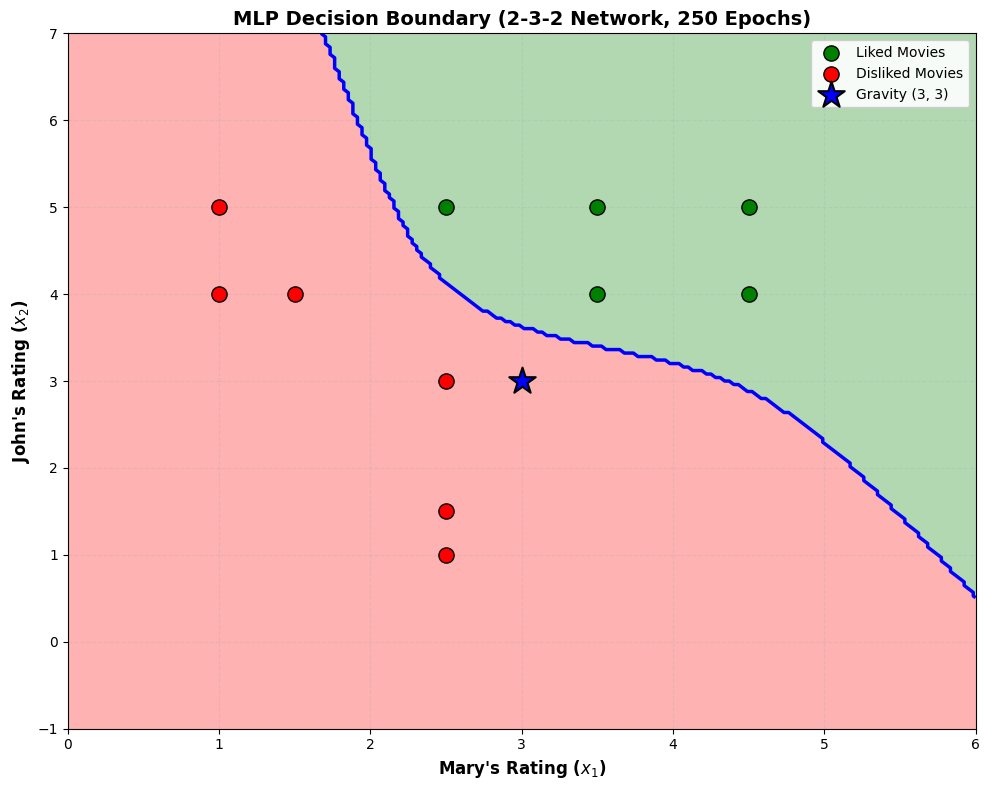

Grid predictions shape: (200, 200)
[[-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ... -1. -1. -1.]
 ...
 [-1. -1. -1. ...  1.  1.  1.]
 [-1. -1. -1. ...  1.  1.  1.]
 [-1. -1. -1. ...  1.  1.  1.]]


In [47]:
import matplotlib.pyplot as plt

# HINT:
# Make sure to have grid_predictions - a 2D array of the same shape as the grid (xx, yy) where each entry is +1 for "Like" and -1 for "Dislike"
# grid_predictions = np.zeros(xx.shape)
# grid_predictions[row, col] = 1 if out[0, 0] > out[1, 0] else -1
### BEGIN SOLUTION

print("=" * 60)
print("PART (j): Decision Boundary Visualization")
print("=" * 60)

# Prepare training data arrays for plotting
X_liked = np.array([[m, j] for m, j in zip(mary_liked, john_liked)])
X_disliked = np.array([[m, j] for m, j in zip(mary_disliked, john_disliked)])

# Create a fine grid over the input space
x1_grid = np.linspace(0, 6, 200)  # Mary's ratings
x2_grid = np.linspace(-1, 7, 200)  # John's ratings
xx, yy = np.meshgrid(x1_grid, x2_grid)

print("\nGenerating decision boundary...")
print(
    f"  Grid size: {xx.shape[0]} × {xx.shape[1]} = {xx.shape[0] * xx.shape[1]:,} points"
)

# Classify every grid point with the trained MLP
grid_predictions = np.zeros(xx.shape)
for row in range(xx.shape[0]):
    for col in range(xx.shape[1]):
        x_pt = np.array([[xx[row, col]], [yy[row, col]]])
        _, acts = feedforward(weights, biases, x_pt)
        out = acts[-1]
        # Assign +1 for "Like" (output[0] > output[1]), -1 for "Dislike"
        grid_predictions[row, col] = 1 if out[0, 0] > out[1, 0] else -1

print("✓ Decision boundary computed")
print("\nGenerating plot...")

# --- Create the plot ---
plt.figure(figsize=(10, 8))

# Background shading for the two regions
plt.contourf(
    xx, yy, grid_predictions, alpha=0.3, levels=[-2, 0, 2], colors=["red", "green"]
)

# Decision boundary contour (where prediction = 0)
contour = plt.contour(
    xx, yy, grid_predictions, levels=[0], colors="blue", linewidths=2.5
)

# Training samples
plt.scatter(
    X_liked[:, 0],
    X_liked[:, 1],
    c="green",
    edgecolors="black",
    s=120,
    label="Liked Movies",
    zorder=5,
    marker="o",
)
plt.scatter(
    X_disliked[:, 0],
    X_disliked[:, 1],
    c="red",
    edgecolors="black",
    s=120,
    label="Disliked Movies",
    zorder=5,
    marker="o",
)

# Mark "Gravity" test point
plt.scatter(
    3,
    3,
    c="blue",
    marker="*",
    s=400,
    edgecolors="black",
    linewidths=1.5,
    label="Gravity (3, 3)",
    zorder=6,
)

# Labels and formatting
plt.xlabel("Mary's Rating ($x_1$)", fontsize=12, fontweight="bold")
plt.ylabel("John's Rating ($x_2$)", fontsize=12, fontweight="bold")
plt.title(
    "MLP Decision Boundary (2-3-2 Network, 250 Epochs)", fontsize=14, fontweight="bold"
)
plt.legend(loc="best", fontsize=10, framealpha=0.9)
plt.xlim(0, 6)
plt.ylim(-1, 7)
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()

print("✓ Plot generated successfully")
print("=" * 60)

plt.show()
### END SOLUTION
print("Grid predictions shape:", grid_predictions.shape)
print(grid_predictions)

In [48]:
### BEGIN HIDDEN TESTS
# TEST: Verify decision boundary computation
print("\nTEST: Decision Boundary Verification")
print("-" * 50)

# Verify grid predictions
assert grid_predictions.shape == xx.shape, "Grid predictions shape matches input grid"
assert np.all((grid_predictions == 1) | (grid_predictions == -1)), (
    "All predictions are +1 or -1"
)

# Count regions
like_region = np.sum(grid_predictions == 1)
dislike_region = np.sum(grid_predictions == -1)

print(f"✓ Grid size: {xx.shape[0]} × {xx.shape[1]}")
print(f"✓ Like region points: {like_region:,}")
print(f"✓ Dislike region points: {dislike_region:,}")
print("✓ Decision boundary test passed")
### END HIDDEN TESTS


TEST: Decision Boundary Verification
--------------------------------------------------
✓ Grid size: 200 × 200
✓ Like region points: 13,541
✓ Dislike region points: 26,459
✓ Decision boundary test passed
